# Dynamical Systems: Lorenz Quantum Reservoir Regime Classification

Classify Lorenz-system regimes from short trajectory summaries using a general quantum reservoir classifier and quantum kernel tools.

## Problem, Variables, and Quantum Advantage Context

**Physics/math problem.** Distinguish settled and chaotic Lorenz parameter regimes from compact trajectory statistics.

**Explicit variables.** `rho_values` controls the Lorenz regime, `features` are trajectory summaries, and `res_pred` contains quantum-reservoir predictions.

**Quantum advantage context.** Quantum reservoirs are nonlinear feature maps that can be useful for dynamical signals. This notebook uses them as a general classifier and keeps a classical baseline.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if repo_root.name == "real_examples":
    repo_root = repo_root.parents[1]
elif repo_root.name == "notebooks":
    repo_root = repo_root.parent

package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from qml import (
    QuantumGaussianProcessRegressor,
    QuantumKernel,
    QuantumKernelClassifier,
    QuantumKernelPCA,
    QuantumKernelRegressor,
    QuantumOneClassClassifier,
    QuantumReservoirClassifier,
    QuantumReservoirFeatures,
    QuantumReservoirRegressor,
    TrainableQuantumKernelRegressor,
)
from qml.reporting import print_section


## Domain simulator

A small Euler integrator generates Lorenz trajectories and extracts summary statistics. This remains local notebook code.

In [2]:
def lorenz_summary(rho, *, steps=420, dt=0.01, discard=120):
    sigma = 10.0
    beta = 8.0 / 3.0
    state = np.array([1.0, 1.0, 1.0], dtype=float)
    traj = []
    for step in range(steps):
        x, y, z = state
        deriv = np.array([
            sigma * (y - x),
            x * (rho - z) - y,
            x * y - beta * z,
        ])
        state = state + dt * deriv
        if step >= discard:
            traj.append(state.copy())
    traj = np.asarray(traj)
    return np.asarray([
        traj[:, 0].std(),
        traj[:, 1].std(),
        traj[:, 2].std(),
        np.mean(np.linalg.norm(np.diff(traj, axis=0), axis=1)),
    ])

rng = np.random.default_rng(601)
steady_rho = rng.uniform(12.0, 20.0, size=20)
chaotic_rho = rng.uniform(26.0, 34.0, size=20)
rho_values = np.concatenate([steady_rho, chaotic_rho])
y = np.concatenate([np.zeros_like(steady_rho, dtype=int), np.ones_like(chaotic_rho, dtype=int)])
features = np.asarray([lorenz_summary(rho) for rho in rho_values])
features += rng.normal(0.0, 0.03, size=features.shape)

x_train, x_test, y_train, y_test, rho_train, rho_test = train_test_split(
    features, y, rho_values, test_size=0.3, random_state=601, stratify=y
)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print_section(
    "Dataset",
    [
        ("Problem", "Lorenz regime classification"),
        ("Samples", int(len(y))),
        ("Classes", {0: "settled/periodic", 1: "chaotic"}),
        ("Features", ["std_x", "std_y", "std_z", "mean_step_speed"]),
    ],
)


Dataset
+----------+----------------------------------------+
| Metric   | Value                                  |
+----------+----------------------------------------+
| Problem  | Lorenz regime classification           |
| Samples  | 40                                     |
| Classes  | {0: 'settled/periodic', 1: 'chaotic'}  |
| Features | [std_x, std_y, std_z, mean_step_speed] |
+----------+----------------------------------------+



## Package-client regime classifiers

In [3]:
reservoir = QuantumReservoirClassifier(
    QuantumReservoirFeatures(n_qubits=4, n_layers=2, seed=601),
    c=1.0,
)
reservoir.fit(x_train, y_train)
res_pred = reservoir.predict(x_test)

kernel = QuantumKernel(embedding="iqp", seed=602)
kpca = QuantumKernelPCA(kernel, n_components=2)
z_train = kpca.fit_transform(x_train)
z_test = kpca.transform(x_test)

qkernel = QuantumKernelClassifier(QuantumKernel(embedding="iqp", seed=603), c=1.0)
qkernel.fit(x_train, y_train)
qk_pred = qkernel.predict(x_test)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(x_train, y_train)
base_pred = logreg.predict(x_test)

results = {
    "quantum_reservoir_accuracy": accuracy_score(y_test, res_pred),
    "quantum_kernel_accuracy": accuracy_score(y_test, qk_pred),
    "logistic_accuracy": accuracy_score(y_test, base_pred),
}

print_section(
    "Results",
    [
        ("Quantum reservoir accuracy", results["quantum_reservoir_accuracy"]),
        ("Quantum kernel accuracy", results["quantum_kernel_accuracy"]),
        ("Logistic accuracy", results["logistic_accuracy"]),
    ],
)


Results
+----------------------------+----------+
| Metric                     | Value    |
+----------------------------+----------+
| Quantum reservoir accuracy | 0.916667 |
| Quantum kernel accuracy    | 1        |
| Logistic accuracy          | 1        |
+----------------------------+----------+



## Plots

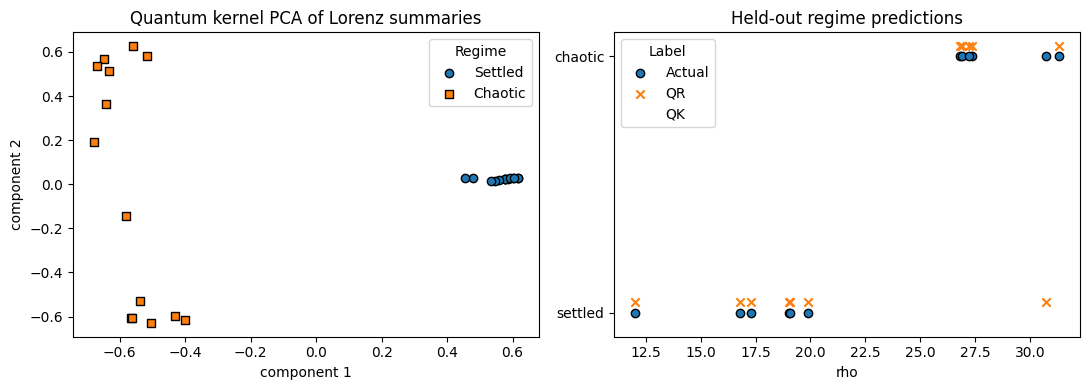

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for cls, name, marker in [(0, "Settled", "o"), (1, "Chaotic", "s")]:
    mask = y_train == cls
    axes[0].scatter(
        z_train[mask, 0],
        z_train[mask, 1],
        marker=marker,
        label=name,
        edgecolor="black",
    )
axes[0].set_title("Quantum kernel PCA of Lorenz summaries")
axes[0].set_xlabel("component 1")
axes[0].set_ylabel("component 2")
axes[0].legend(title="Regime")

axes[1].scatter(rho_test, y_test, label="Actual", edgecolor="black")
axes[1].scatter(rho_test, res_pred + 0.04, marker="x", label="QR")
axes[1].scatter(rho_test, qk_pred - 0.04, marker="s", facecolors="none", label="QK")
axes[1].set_title("Held-out regime predictions")
axes[1].set_xlabel("rho")
axes[1].set_yticks([0, 1], ["settled", "chaotic"])
axes[1].legend(title="Label")
plt.tight_layout()
plt.show()


## Validation block

In [5]:
validation = {
    "dataset": {
        "problem": "lorenz_regime_classification_with_reservoir",
        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),
        "feature_count": int(x_train.shape[1]),
    },
    "results": results,
    "sample_predictions": [
        {"rho": float(r), "actual": int(a), "reservoir": int(p), "kernel": int(k)}
        for r, a, p, k in zip(rho_test[:8], y_test[:8], res_pred[:8], qk_pred[:8])
    ],
    "passed": bool(
        results["quantum_reservoir_accuracy"] >= 0.7
        and results["quantum_kernel_accuracy"] >= 0.7
        and np.isfinite(z_train).all()
    ),
}

print("Validation")
print_section("Dataset", validation["dataset"].items())
print_section("Results", validation["results"].items())
print_section("Sample predictions", validation["sample_predictions"][:5])
print_section("Passed", [("passed", validation["passed"])])


Validation
Dataset
+---------------+---------------------------------------------+
| Metric        | Value                                       |
+---------------+---------------------------------------------+
| problem       | lorenz_regime_classification_with_reservoir |
| n_train       | 28                                          |
| n_test        | 12                                          |
| feature_count | 4                                           |
+---------------+---------------------------------------------+

Results
+----------------------------+----------+
| Metric                     | Value    |
+----------------------------+----------+
| quantum_reservoir_accuracy | 0.916667 |
| quantum_kernel_accuracy    | 1        |
| logistic_accuracy          | 1        |
+----------------------------+----------+

Sample predictions
+---------+--------+-----------+--------+
| rho     | actual | reservoir | kernel |
+---------+--------+-----------+--------+
| 31.3047 | 1      |